In [ ]:
#!/usr/bin/env python3
# train_FG_long_k.py
# Convert wide (ETA, F1..F12, G1..G12) -> long dataset with mapping k->(Ri,M)
# Train NN to predict (Fval,Gval) from inputs (Ri, M, Eta, k).
# Optional: you can later extend pde_residuals(...) and set USE_PDE=True for PINN.

import os, time, json
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------------- User settings ----------------
DATA_PATH = "Grad-3Ec-Merged.csv"   # your CSV
OUT_DIR = "pinn_fg_long_out_3"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# mapping k -> (Phi) as you described
k_map = {
    1: (1), 2: (2), 3: (3),
    4: (3),  5: (5)
    }

# training hyperparams (tune)
SEED = 42
N_EPOCHS = 1600
BATCH_SIZE = 128
LR = 2e-3
ONECYCLE_MAX_LR = 8e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 300
PRINT_EVERY = 80

USE_PDE = False   # set True only after you implement pde_residuals()
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)

# ---------------- Load CSV and build long dataset ----------------
df_w = pd.read_csv(DATA_PATH)
print("Loaded CSV:", DATA_PATH, "shape:", df_w.shape)
print("Columns:", df_w.columns.tolist()[:20])

# find ETA column
eta_col = next((c for c in df_w.columns if c.strip().lower()=='eta' or 'eta' in c.lower()), None)
if eta_col is None:
    raise RuntimeError("ETA column not found in CSV.")

# check F/G columns exist
Cf_cols = [f"Cf{i}" for i in range(1,7)]
#G_cols = [f"G{i}" for i in range(1,13)]
for c in Cf_cols:
    if c not in df_w.columns:
        raise RuntimeError(f"Column {c} not found in CSV.")

# Build long records: for each k create rows with assigned Ri,M
records = []
n_eta = df_w.shape[0]
for k in range(1,7):
    ri, m = k_map[k]
    Cf_col = f"Cf{k}"
    for i in range(n_eta):
        records.append({
            "Ri": ri,
            "M": m,
            "Eta": float(df_w.iloc[i][eta_col]),
            "k": float(k),           # include k as numeric (we'll normalize)
            "Cf_val": float(df_w.iloc[i][Cf_col]),
            #"Gval": float(df_w.iloc[i][Gcol])
        })
df = pd.DataFrame.from_records(records)
print("Built long dataframe shape:", df.shape)
df.to_csv(os.path.join(OUT_DIR,"Cf_long_raw.csv"), index=False)



Loaded CSV: Grad-6-Merged.csv shape: (402, 6)
Columns: ['ETA', 'Pi1', 'Pi2', 'Pi3', 'Pi4', 'Pi5']


RuntimeError: Column Cf1 not found in CSV.

In [5]:
# ---------------- Attention-based model (replace previous broken MHA usage) ----------------
import os, time, json
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------- fallback defaults (only used if not defined earlier) ----------
try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    OUT_DIR
except NameError:
    OUT_DIR = "pinn_fg_long_out_attn"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = globals().get("SEED", 42)
N_EPOCHS = globals().get("N_EPOCHS", 1600)
BATCH_SIZE = globals().get("BATCH_SIZE", 128)
LR = globals().get("LR", 2e-3)
ONECYCLE_MAX_LR = globals().get("ONECYCLE_MAX_LR", 8e-3)
GRAD_CLIP = globals().get("GRAD_CLIP", 5.0)
LBFGS_ITERS = globals().get("LBFGS_ITERS", 200)
EARLY_STOPPING_PATIENCE = globals().get("EARLY_STOPPING_PATIENCE", 300)
PRINT_EVERY = globals().get("PRINT_EVERY", 80)

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- Prepare model inputs/outputs (rebuild to be self-contained) ----------------
# expects df with columns Ri,M,Eta,k,Cf_val
assert all(c in df.columns for c in ["Ri","M","Eta","k","Cf_val"]), "df must contain Ri,M,Eta,k,Cf_val"

X = df[["Ri","M","Eta","k"]].values.astype(np.float32)
Y = df[["Cf_val"]].values.astype(np.float32)

# Normalize inputs and target per-column
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# train/val/test split stratified by Ri_M combos
df["combo"] = df["Ri"].astype(str) + "_" + df["M"].astype(str)
idxs = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idxs, test_size=0.18, random_state=SEED, stratify=df['combo'])
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_all   = Xn.copy()

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], Xn.shape[0]-X_train.shape[0]-X_val.shape[0])

# convert to torch tensors
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(X_all, dtype=torch.float32, device=device)
Yn_t      = torch.tensor(Yn, dtype=torch.float32, device=device)

# ---------------- Attention model components ----------------
class Tokenizer(nn.Module):
    """Project 4 scalar inputs into 4 token embeddings (N, seq=4, token_dim)"""
    def __init__(self, token_dim=64):
        super().__init__()
        self.embed_Ri  = nn.Linear(1, token_dim)
        self.embed_M   = nn.Linear(1, token_dim)
        self.embed_Eta = nn.Linear(1, token_dim)
        self.embed_k   = nn.Linear(1, token_dim)
        self.act = nn.SiLU()
    def forward(self, x):
        # x: (N,4) order [Ri,M,Eta,k]
        Ri  = self.act(self.embed_Ri(x[:,0:1]))
        M   = self.act(self.embed_M(x[:,1:2]))
        Eta = self.act(self.embed_Eta(x[:,2:3]))
        k   = self.act(self.embed_k(x[:,3:4]))
        tokens = torch.stack([Ri, M, Eta, k], dim=1)   # (N,4,token_dim)
        return tokens

class AttentionBlock(nn.Module):
    """Single attention block with residual and FFN"""
    def __init__(self, token_dim=64, num_heads=4, ff_mult=4, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=token_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(token_dim)
        self.ff = nn.Sequential(
            nn.Linear(token_dim, token_dim*ff_mult),
            nn.SiLU(),
            nn.Linear(token_dim*ff_mult, token_dim)
        )
        self.ln2 = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, tokens):
        # tokens: (N, seq, token_dim)
        attn_out, _ = self.mha(tokens, tokens, tokens)   # (N, seq, token_dim)
        x = self.ln1(tokens + self.dropout(attn_out))
        ff_out = self.ff(x)
        out = self.ln2(x + self.dropout(ff_out))
        return out

class AttentionPINN(nn.Module):
    def __init__(self, token_dim=64, num_heads=4, n_blocks=3, out_dim=1):
        super().__init__()
        self.tokenizer = Tokenizer(token_dim=token_dim)
        self.pos_emb = nn.Parameter(torch.randn(1, 4, token_dim) * 0.01)
        self.blocks = nn.ModuleList([AttentionBlock(token_dim=token_dim, num_heads=num_heads) for _ in range(n_blocks)])
        # pooling + head
        self.pool = nn.Sequential(
            nn.Flatten(),                      # (N, 4*token_dim)
            nn.Linear(4*token_dim, token_dim),
            nn.SiLU(),
            nn.Linear(token_dim, out_dim)
        )
        # init
        for p in self.modules():
            if isinstance(p, nn.Linear):
                nn.init.xavier_uniform_(p.weight); 
                if p.bias is not None: nn.init.zeros_(p.bias)
    def forward(self, x):
        # x: (N,4)
        tokens = self.tokenizer(x) + self.pos_emb   # (N,4,token_dim)
        for blk in self.blocks:
            tokens = blk(tokens)
        out = self.pool(tokens)   # (N, out_dim)
        return out

# ---------------- Instantiate model ----------------
model = AttentionPINN(token_dim=64, num_heads=4, n_blocks=3, out_dim=1).to(device)
print("Model params:", sum(p.numel() for p in model.parameters()))

# ---------------- Optimizer + Scheduler ----------------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
steps_per_epoch = max(1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE))))
total_steps = N_EPOCHS * steps_per_epoch
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=ONECYCLE_MAX_LR,
                                          total_steps=total_steps, pct_start=0.1, div_factor=10.0)
mse = nn.MSELoss()

# ---------------- Training loop ----------------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    losses = []
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device)
        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)
        optimizer.zero_grad()
        pred = model(xb)                     # (batch,1)
        loss = mse(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    model.eval()
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device))
        val_loss = float(mse(val_pred, torch.tensor(Y_val, dtype=torch.float32, device=device)).item())

    history['train'].append(train_loss); history['val'].append(val_loss)
    if ep % PRINT_EVERY == 0 or ep==1:
        print(f"Epoch {ep}/{N_EPOCHS}  train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_attn.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep); break

t1 = time.time()
print("Training finished in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))
# load best
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_attn.pt"), map_location=device))
model.eval()

# ---------------- LBFGS refinement (optional) ----------------
print("LBFGS refine (optional)...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, Yn_t)
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()   # normalized predictions
Ypred = Ypred_n * Y_std + Y_mean            # invert normalization (original scale)

# attach predictions to df and save
df['p_Cf_val'] = Ypred[:,0]
out_csv = os.path.join(OUT_DIR, "Cf_long_preds_attn.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# save training history and norm params
np.savez(os.path.join(OUT_DIR,"norm_params_attn.npz"), X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std)
with open(os.path.join(OUT_DIR,"history_attn.json"), "w") as f:
    json.dump(history, f)

print("Done. Results saved in:", OUT_DIR)


Train/Val/Test sizes: 1977 217 218
Model params: 167233
Epoch 1/1600  train=1.529e+00 val=1.386e+00 lr=8.01e-04
Epoch 80/1600  train=6.385e-01 val=6.949e-01 lr=4.40e-03
Epoch 160/1600  train=1.004e+00 val=1.049e+00 lr=8.00e-03
Epoch 240/1600  train=1.006e+00 val=1.047e+00 lr=7.94e-03
Epoch 320/1600  train=1.008e+00 val=1.049e+00 lr=7.76e-03
Early stopping at epoch 377
Training finished in 588.4s best_val=5.9523e-01
LBFGS refine (optional)...
Saved long-format predictions to: pinn_fg_long_out_3\Cf_long_preds_attn.csv
Done. Results saved in: pinn_fg_long_out_3


In [ ]:
# Compute RMSE overall and per combo and per k
df['err_Cf2'] = (df['p_Cf_val'] - df['Cf_val'])**2

rmse_overall = np.sqrt(df[['err_Cf2']].mean(axis=0))
print("Overall RMSE (Cf):", rmse_overall.tolist())

# per k RMSE
rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))

rmse_df = pd.DataFrame({'k': rmse_k.index, 'rmse_F': rmse_k.values})
rmse_df.to_csv(os.path.join(OUT_DIR,"rmse_per_k.csv"), index=False)
print("Saved rmse_per_k.csv")

# ---------------- plots: reconstruct curves per k (Ri,M) ----------------
for k in sorted(df['k'].unique()):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    plt.figure(figsize=(8,4))
    plt.plot(sub['Eta'], sub['Cf_val'], '-', label='Cf true')
    plt.plot(sub['Eta'], sub['p_Cf_val'], '--', label='Cf pred')
    
    plt.title(f"k={int(k)} Ri={ri} M={m}")
    plt.legend()
    plt.xlabel("Eta")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"curve_k{k}_Ri{ri}_M{m}.png"))
    plt.close()

print("Saved curve plots and parity/rmse info in", OUT_DIR)

Overall RMSE (Cf): [8.605061132336198]
Saved rmse_per_k.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_8332\538526870.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))


Saved curve plots and parity/rmse info in pinn_fg_long_out_3


In [7]:
# LBFGS refine (optional)
print("LBFGS refine...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, torch.tensor(Yn, dtype=torch.float32, device=device))
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()
Ypred = Ypred_n * Y_std + Y_mean   # invert normalization

# attach predictions to df and save
df['p_Fval'] = Ypred[:,0]

out_csv = os.path.join(OUT_DIR, "Cf_long_preds.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# Compute RMSE overall and per combo and per k
df['err_Cf2'] = (df['p_Cf_val'] - df['Cf_val'])**2

rmse_overall = np.sqrt(df[['err_Cf2']].mean(axis=0))
print("Overall RMSE (F,G):", rmse_overall.tolist())

# per k RMSE
rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))

rmse_df = pd.DataFrame({'k': rmse_k.index, 'rmse_F': rmse_k.values})
rmse_df.to_csv(os.path.join(OUT_DIR,"rmse_per_k.csv"), index=False)
print("Saved rmse_per_k.csv")

# ---------------- plots: reconstruct curves per k (Ri,M) ----------------
for k in sorted(df['k'].unique()):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    plt.figure(figsize=(8,4))
    plt.plot(sub['Eta'], sub['Cf_val'], '-', label='Cf true')
    plt.plot(sub['Eta'], sub['p_Cf_val'], '--', label='Cf pred')
    
    plt.title(f"k={int(k)} Ri={ri} M={m}")
    plt.legend()
    plt.xlabel("Eta")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"curve_k{k}_Ri{ri}_M{m}.png"))
    plt.close()

print("Saved curve plots and parity/rmse info in", OUT_DIR)

LBFGS refine...
Saved long-format predictions to: pinn_fg_long_out_3\Cf_long_preds.csv
Overall RMSE (F,G): [8.605061132336198]
Saved rmse_per_k.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_8332\3536895014.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))


Saved curve plots and parity/rmse info in pinn_fg_long_out_3


In [12]:
# === Attention-based PINN with tail (Eta>2.5) derivative penalty ===
# Paste/replace your previous training block with this.
import os, time, json, math
from copy import deepcopy
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------- SETTINGS (tweak these) ----------
OUT_DIR = "pinn_attn_tail_fix"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
N_EPOCHS = 1600
BATCH_SIZE = 128
LR = 1.5e-3              # slightly lower max lr for stability in tails
ONECYCLE_MAX_LR = 6e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 300
PRINT_EVERY = 80

# Tail handling
ETA_THRESHOLD = 2.5     # region where curve becomes flat
ETA_WEIGHT = 1.5        # slight upweight of tail samples (1.0 = no upweight)
DERIV_PENALTY = 1.0     # penalty coefficient on |d(pred)/dEta| in tail (tune 0.1-5.0)

# Model architecture
TOKEN_DIM = 64
NUM_HEADS = 4
N_BLOCKS = 3
FF_MULT = 4

os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------- verify df has required columns ----------
required_cols = ["Ri","M","Eta","k","Cf_val"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise RuntimeError("DataFrame 'df' missing columns: " + ", ".join(missing))

# ---------- Build dataset arrays ----------
X = df[["Ri","M","Eta","k"]].values.astype(np.float32)  # shape (N,4)
Y = df[["Cf_val"]].values.astype(np.float32)            # shape (N,1)

# Diagnostics
eta_raw = X[:,2]
n_total = len(eta_raw)
n_tail = int((eta_raw > ETA_THRESHOLD).sum())
print(f"Total samples: {n_total}, tail (Eta>{ETA_THRESHOLD}): {n_tail} ({100.0*n_tail/n_total:.1f}%)")

# ---------- Normalization ----------
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# Keep raw arrays for tail detection in batches
X_raw = X.copy()
X_train_raw = None  # will set after splitting

# ---------- Train/val/test split (stratified by Ri_M combos) ----------
df["combo"] = df["Ri"].astype(str) + "_" + df["M"].astype(str)
idx = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idx, test_size=0.18, random_state=SEED, stratify=df['combo'])
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_test  = Xn[test_idx];  Y_test  = Yn[test_idx]
X_train_raw = X_raw[train_idx]; X_val_raw = X_raw[val_idx]; X_all_raw = X_raw

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# convert to torch tensors
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(Xn, dtype=torch.float32, device=device)
Yn_t      = torch.tensor(Yn, dtype=torch.float32, device=device)

# ---------- Fourier features helper for Eta ----------
class FourierFeatures(nn.Module):
    def __init__(self, in_dim=1, out_dim=32, max_freq=10.0):
        super().__init__()
        B = torch.randn(out_dim//2, in_dim) * max_freq
        self.register_buffer("B", B)
        self.out_dim = out_dim
    def forward(self, x):   # x: (N,1)
        proj = 2*math.pi * (x @ self.B.T)    # (N, out_dim//2)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (N, out_dim)

# ---------- Tokenizer (Ri,M,Eta,k -> tokens) ----------
class Tokenizer(nn.Module):
    def __init__(self, token_dim=TOKEN_DIM, eta_ff_dim=32, eta_max_freq=10.0):
        super().__init__()
        self.embed_Ri = nn.Linear(1, token_dim)
        self.embed_M = nn.Linear(1, token_dim)
        self.ff_eta = FourierFeatures(1, out_dim=eta_ff_dim, max_freq=eta_max_freq)
        self.proj_eta = nn.Linear(eta_ff_dim, token_dim)
        self.embed_k = nn.Linear(1, token_dim)   # treat k as numeric; could use embedding
        self.act = nn.SiLU()
    def forward(self, x):
        # x: (N,4) -> [Ri,M,Eta,k] (normalized)
        Ri = self.act(self.embed_Ri(x[:,0:1]))
        M  = self.act(self.embed_M(x[:,1:2]))
        Eta_ff = self.ff_eta(x[:,2:3])
        Eta = self.act(self.proj_eta(Eta_ff))
        k  = self.act(self.embed_k(x[:,3:4]))
        tokens = torch.stack([Ri, M, Eta, k], dim=1)  # (N,4,token_dim)
        return tokens

# ---------- Attention Block ----------
class AttentionBlock(nn.Module):
    def __init__(self, token_dim=TOKEN_DIM, num_heads=NUM_HEADS, ff_mult=FF_MULT, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=token_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(token_dim)
        self.ff = nn.Sequential(
            nn.Linear(token_dim, token_dim*ff_mult),
            nn.SiLU(),
            nn.Linear(token_dim*ff_mult, token_dim)
        )
        self.ln2 = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, tokens):
        attn_out, _ = self.mha(tokens, tokens, tokens)
        x = self.ln1(tokens + self.dropout(attn_out))
        ff_out = self.ff(x)
        out = self.ln2(x + self.dropout(ff_out))
        return out

# ---------- Attention PINN model ----------
class AttentionPINN(nn.Module):
    def __init__(self, token_dim=TOKEN_DIM, num_heads=NUM_HEADS, n_blocks=N_BLOCKS, out_dim=1):
        super().__init__()
        self.tokenizer = Tokenizer(token_dim=token_dim, eta_ff_dim=32, eta_max_freq=10.0)
        self.pos_emb = nn.Parameter(torch.randn(1, 4, token_dim) * 0.01)
        self.blocks = nn.ModuleList([AttentionBlock(token_dim=token_dim, num_heads=num_heads, ff_mult=FF_MULT, dropout=0.0) for _ in range(n_blocks)])
        self.pool = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*token_dim, token_dim),
            nn.SiLU(),
            nn.Linear(token_dim, out_dim)
        )
        # init linear weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        # x: (N,4) normalized
        tokens = self.tokenizer(x) + self.pos_emb
        for blk in self.blocks:
            tokens = blk(tokens)
        out = self.pool(tokens)   # (N,out_dim)
        return out

# ---------- Create model ----------
model = AttentionPINN(token_dim=TOKEN_DIM, num_heads=NUM_HEADS, n_blocks=N_BLOCKS, out_dim=1).to(device)
print("Model parameters:", sum(p.numel() for p in model.parameters()))

# ---------- Optimizer + Scheduler ----------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
steps_per_epoch = max(1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE))))
total_steps = N_EPOCHS * steps_per_epoch
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=ONECYCLE_MAX_LR,
                                          total_steps=total_steps, pct_start=0.08, div_factor=10.0)
mse = nn.MSELoss(reduction='mean')

# ---------- Training (with tail derivative penalty) ----------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()

for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    batch_losses = []
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device, requires_grad=False)
        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)

        # tail info using raw Eta (un-normalized)
        eta_batch_raw = torch.tensor(X_train_raw[idxb, 2:3], dtype=torch.float32, device=device)

        optimizer.zero_grad()
        pred = model(xb)   # normalized-space prediction (shape (b,1))

        # data loss (MSE) in normalized target space
        data_loss = mse(pred, yb)

        # tail upweighting
        w = torch.ones_like(data_loss)  # scalar baseline
        # compute sample-wise weights for batch (vector)
        # but easier to compute weighted MSE: compute elementwise squared errors first
        sq_err = (pred - yb)**2  # (b,1)
        sample_weights = torch.ones_like(sq_err, device=device)
        sample_weights[eta_batch_raw > ETA_THRESHOLD] = ETA_WEIGHT
        weighted_data_loss = (sample_weights * sq_err).mean()

        # derivative penalty in tail: need prediction wrt Eta (original scale)
        # To compute derivative, we must feed model a tensor where the Eta coordinate requires_grad.
        # We'll reconstruct a small tensor with requires_grad for this batch's tail samples only.
        deriv_pen = torch.tensor(0.0, device=device)
        if DERIV_PENALTY > 0.0:
            tail_mask = (eta_batch_raw > ETA_THRESHOLD).squeeze(-1)   # boolean vector
            if tail_mask.any():
                # Build inputs for tail rows where Eta requires grad (use normalized Xi)
                tail_idx = np.nonzero(tail_mask.cpu().numpy())[0]
                xb_tail = torch.tensor(X_train[idxb][tail_idx], dtype=torch.float32, device=device, requires_grad=True)
                # xb_tail shape (nt,4)
                pred_tail = model(xb_tail)  # (nt,1)
                # derivative w.r.t. Eta: xb_tail[:,2] is normalized Eta; need d(pred)/d(Eta_raw).
                # chain rule: pred w.r.t normalized Eta * d(normalized Eta)/d(raw Eta) = pred_grad / X_std[2]
                pred_tail_sum = pred_tail.sum()
                grads = torch.autograd.grad(pred_tail_sum, xb_tail, create_graph=True)[0]  # (nt,4)
                # grads[:,2] is derivative wrt normalized Eta
                dpred_deta_norm = grads[:,2:3]  # shape (nt,1)
                # convert to derivative wrt raw Eta: divide by X_std[2]
                dpred_deta_raw = dpred_deta_norm / (X_std[2] + 1e-12)
                # penalty: square of derivative mean
                deriv_pen = (dpred_deta_raw.abs().mean())**2   # encourage small magnitude (near zero slope)
                # scale by DERIV_PENALTY
                deriv_pen = DERIV_PENALTY * deriv_pen

        # total loss combines weighted data loss + derivative penalty
        loss = weighted_data_loss + deriv_pen

        # backprop
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass

        batch_losses.append(float(loss.detach().cpu().numpy()))

    train_loss = float(np.mean(batch_losses))

    # validation (no tail penalty, normal MSE on validation set)
    model.eval()
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device))
        val_loss = float(mse(val_pred, torch.tensor(Y_val, dtype=torch.float32, device=device)).item())

    history['train'].append(train_loss); history['val'].append(val_loss)
    if ep % PRINT_EVERY == 0 or ep==1:
        print(f"Epoch {ep}/{N_EPOCHS}  train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")

    # early stopping & save best
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_attn_tail.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep)
            break

t1 = time.time()
print("Training finished in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))

# load best
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_attn_tail.pt"), map_location=device))
model.eval()

# ---------- LBFGS refine (optional) ----------
print("LBFGS refine (optional)...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, Yn_t)
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------- Predictions back to original scale ----------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()   # normalized predictions
Ypred = Ypred_n * Y_std + Y_mean            # invert normalization to original Cf scale

df['p_Cf_val'] = Ypred[:,0]
out_csv = os.path.join(OUT_DIR, "Cf_long_preds_attn_tail.csv")
df.to_csv(out_csv, index=False)
print("Saved predictions CSV:", out_csv)

# ---------- Save artifacts ----------
np.savez(os.path.join(OUT_DIR,"norm_params_attn_tail.npz"), X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std)
with open(os.path.join(OUT_DIR,"history_attn_tail.json"), "w") as f:
    json.dump(history, f)

# ---------- Quick diagnostic plots ----------
# overall parity
plt.figure(figsize=(5,5))
plt.scatter(df['Cf_val'], df['p_Cf_val'], s=8, alpha=0.6)
mn = min(df['Cf_val'].min(), df['p_Cf_val'].min()); mx = max(df['Cf_val'].max(), df['p_Cf_val'].max())
plt.plot([mn,mx],[mn,mx],'k--'); plt.xlabel("True Cf"); plt.ylabel("Pred Cf"); plt.title("Parity Cf")
plt.savefig(os.path.join(OUT_DIR,"parity_Cf.png"), dpi=200); plt.close()

# curves by (Ri,M) mapping via k
# If your df has k->(Ri,M) mapping externally, use it; else group by combo
for (ri,m), grp in df.groupby(['Ri','M']):
    gg = grp.sort_values('Eta')
    plt.figure(figsize=(7,4))
    plt.plot(gg['Eta'], gg['Cf_val'], '-', label='true')
    plt.plot(gg['Eta'], gg['p_Cf_val'], '--', label='pred')
    plt.title(f"Ri={ri} M={m}")
    plt.xlabel("Eta"); plt.legend()
    plt.tight_layout()
    fname = os.path.join(OUT_DIR, f"curve_Ri{ri}_M{m}.png")
    plt.savefig(fname, dpi=200); plt.close()

print("Saved plots and artifacts in:", OUT_DIR)


Total samples: 2412, tail (Eta>2.5): 906 (37.6%)
Train/Val/Test sizes: 1977 217 218
Model parameters: 169217
Epoch 1/1600  train=4.181e+02 val=1.048e+00 lr=6.01e-04
Epoch 80/1600  train=5.861e-01 val=4.363e-01 lr=4.34e-03
Epoch 160/1600  train=1.330e+00 val=1.010e+00 lr=5.99e-03
Epoch 240/1600  train=1.165e+00 val=1.037e+00 lr=5.91e-03
Epoch 320/1600  train=1.179e+00 val=1.027e+00 lr=5.75e-03
Early stopping at epoch 384
Training finished in 1131.2s best_val=4.3433e-01
LBFGS refine (optional)...
Saved predictions CSV: pinn_attn_tail_fix\Cf_long_preds_attn_tail.csv
Saved plots and artifacts in: pinn_attn_tail_fix


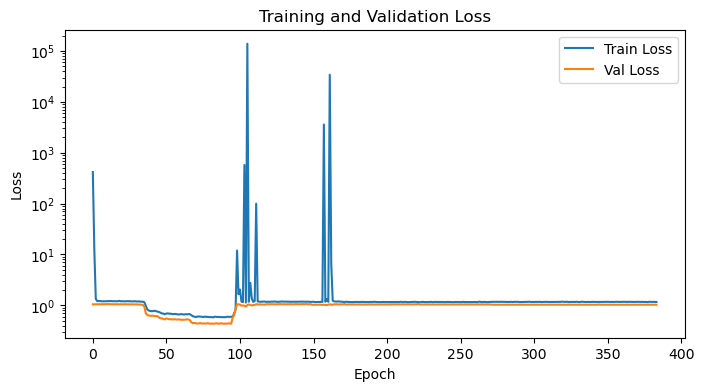

In [13]:
#Plot the training history
plt.figure(figsize=(8,4))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [14]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,7):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Cf_val'], mode='lines', name=f'Cf true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Fval'], mode='lines+markers', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "Cf_values_plotly.html"))
fig.show()

In [15]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,7):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Fval'], mode='lines+markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Cf_val'], mode='lines', name=f'Cf pred k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Gval'], mode='lines+markers', name=f'G true k={int(k)} Ri={ri} M={m}'))
    #fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Gval'], mode='lines+markers', name=f'G pred k={int(k)} Ri={ri} M={m}'))
fig.update_layout(title='Cf values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_Pred_values_plotly.html"))
fig.show()

In [ ]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,7):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Cf_val'], mode='markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Cf_val'], mode='lines', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_F-Pred_values_plotly.html"))
fig.show()